# Model Structure Comparison

This notebook compares the current models defined in `scripts/model_training.py`.

All training, evaluation, and plotting helper logic is kept in `scripts/model_comparison_notebook_helper.py`.


In [37]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
import importlib

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT / "scripts"))

import scripts.model_comparison_notebook_helper as helper
importlib.reload(helper)

pd.set_option("display.max_columns", None)

In [33]:
MODELS_TO_RUN = ["xgboost", "cnn", "lstm", "lstm_attention"]

TRAINING_OVERRIDES = {
    "xgboost": {"n_estimators": 300},
    "cnn": {"epochs": 10, "batch_size": 64},
    "lstm": {"epochs": 10, "batch_size": 64},
    "lstm_attention": {"epochs": 10},
}

MODELS_TO_RUN

['xgboost', 'cnn', 'lstm', 'lstm_attention']

In [34]:
data_bundle = helper.load_experiment_data()
display(helper.build_data_overview(data_bundle))

sequence_bundle = helper.prepare_sequence_bundle(data_bundle)
print("Sequence shapes:")
print("train:", sequence_bundle["train"]["X"].shape)
print("validation:", sequence_bundle["validation"]["X"].shape)
print("test:", sequence_bundle["test"]["X"].shape)

,split,rows,features,start,end,label_dist
0,train,16941,41,2015-02-20,2022-01-25,"{-1: 3924, 0: 8621, 1: 4396}"
1,validation,3629,41,2022-01-26,2023-07-11,"{-1: 830, 0: 1941, 1: 858}"
2,test,3648,41,2023-07-12,2024-12-20,"{-1: 860, 0: 1812, 1: 976}"


Sequence shapes:
train: (16741, 20, 41)
validation: (3629, 20, 41)
test: (3648, 20, 41)


In [35]:
summary_df, artifacts, data_bundle, sequence_bundle = helper.run_model_comparison(
    models_to_run=MODELS_TO_RUN,
    training_overrides=TRAINING_OVERRIDES,
)

display(summary_df)

results_path = ROOT / "results" / "model_structure_comparison_metrics.csv"
summary_df.to_csv(results_path, index=False)
print(f"Saved summary metrics to: {results_path}")

,model,val_accuracy,val_macro_f1,val_weighted_f1,val_auc,test_accuracy,test_macro_f1,test_weighted_f1,test_auc
0,xgboost,0.514467,0.329166,0.434977,0.551851,0.481634,0.336863,0.412433,0.542178
1,cnn,0.338385,0.313596,0.343923,0.503325,0.315789,0.302890,0.326173,0.476031
2,lstm,0.429319,0.373350,0.432917,0.559874,0.398026,0.326315,0.380017,0.523861
3,lstm_attention,0.485533,0.394984,0.471665,0.588930,0.448465,0.366883,0.426487,0.572737


Saved summary metrics to: /Users/equinox19323/Documents/NUS/Semester2/FT5011/ft5011-group/results/model_structure_comparison_metrics.csv


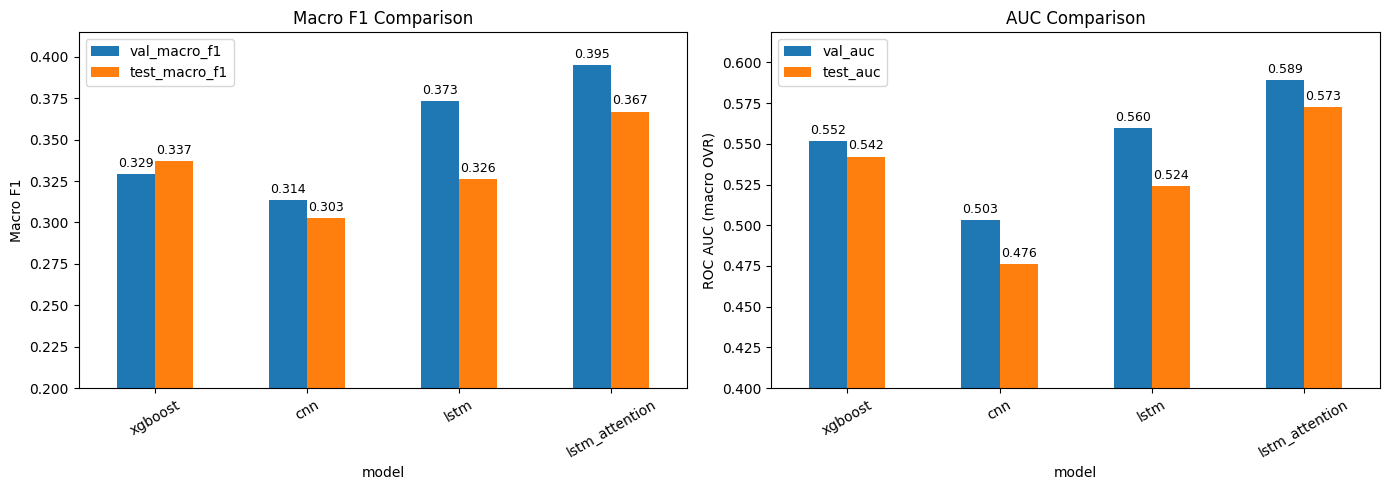

In [38]:
helper.plot_metric_bars(summary_df)

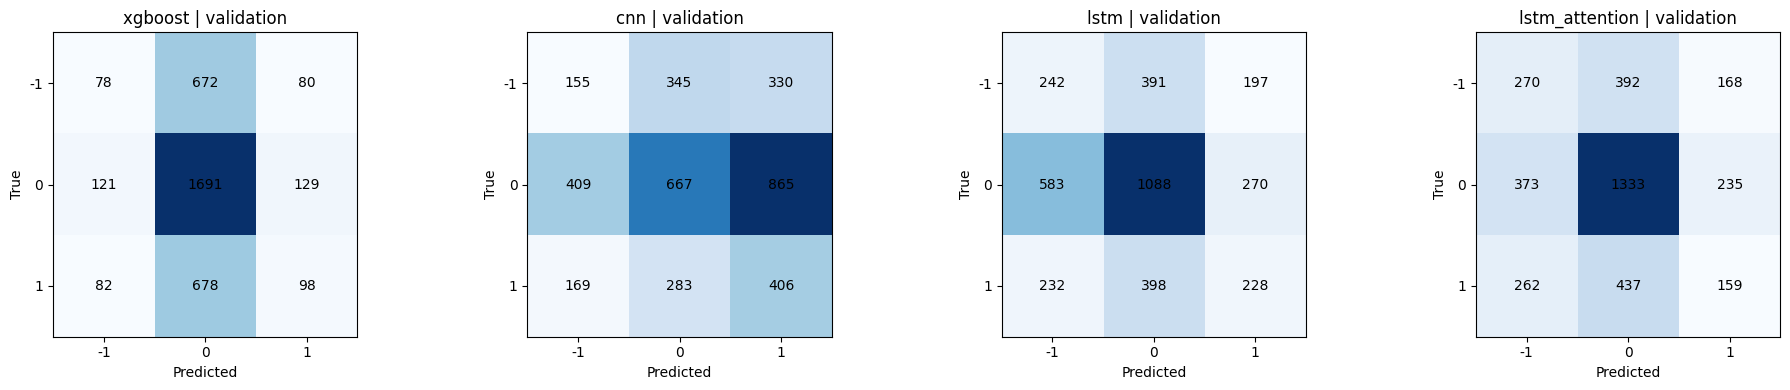

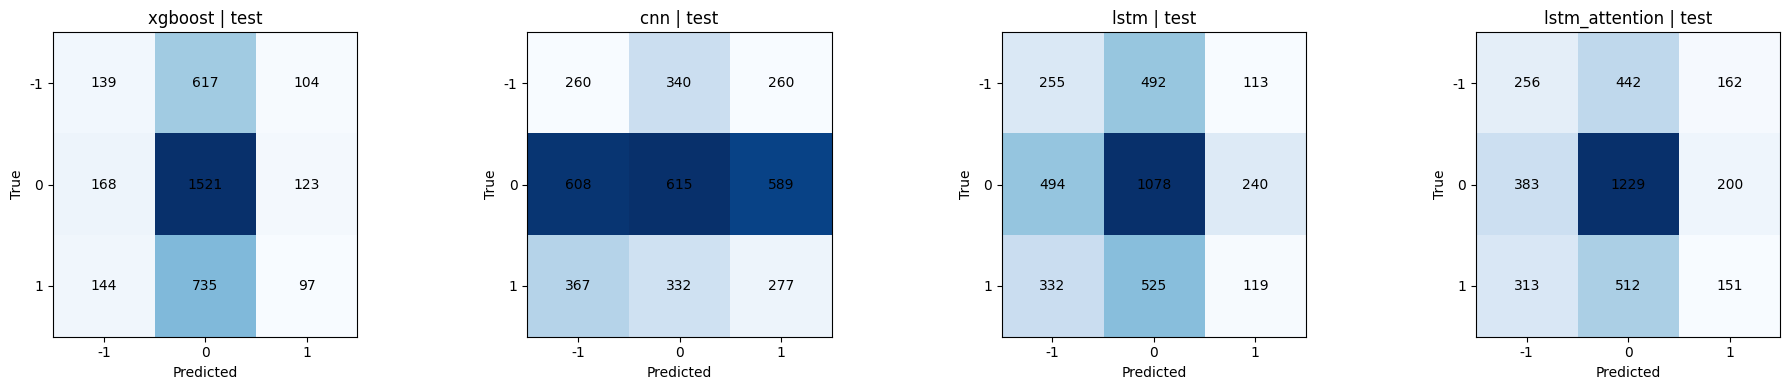

In [39]:
helper.plot_confusion_matrices(artifacts, split_name="validation")
helper.plot_confusion_matrices(artifacts, split_name="test")

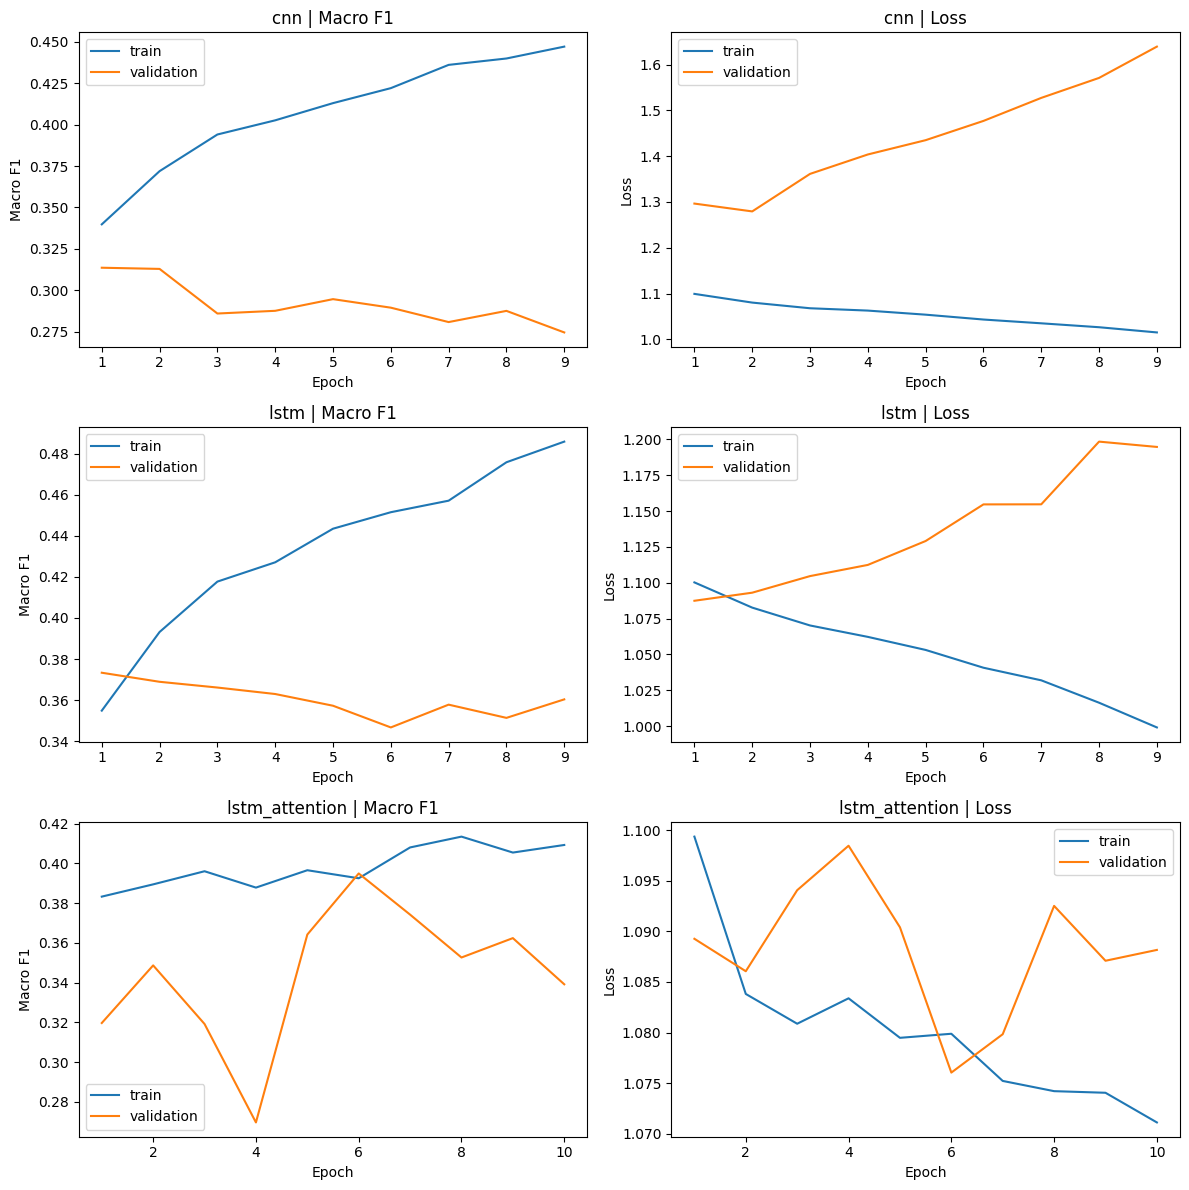

In [40]:
helper.plot_training_curves(artifacts)